# Exercise 7 - FastSlam [15.0]

---

In [1]:
from ex7 import *

#Autoloads evertyhing flaged with %aimport
%load_ext autoreload    
%autoreload 1               
%aimport ex7  

#Matplotlib output to cell
%matplotlib inline 

---
In this assignment, you are required to implement the FastSLAM algorithm. As a SLAM algorithm, FastSLAM enables a robot to simultaneously estimate its own pose and build a map of the environment while navigating within it. The original data was recorded using a Dingo robot in the IPB office environment. During the robot’s traversal, cameras mounted on the robot recorded AprilTags attached to the ceiling.

<img src="robotsetup.png" alt="Robot Setup LILocBench Challenge" title="Setup" width="60%">

Although these recordings were originally used to obtain highly accurate robot localization for the [LILocBench](https://www.codabench.org/competitions/8889/) challenge, this exercise uses only the distance and bearing measurements of a subset of the recorded AprilTags. 

The function `read_world_data` provides you with the ground truth position of the landmarks, and `read_sensor_data` with odometry and rang-bearing readings. The figure below visualizes the map with landmarks and the actual trajectory taken by the robot. While this information is visible to you, it is not for the robot during the exploration, localisation and generation of the map.

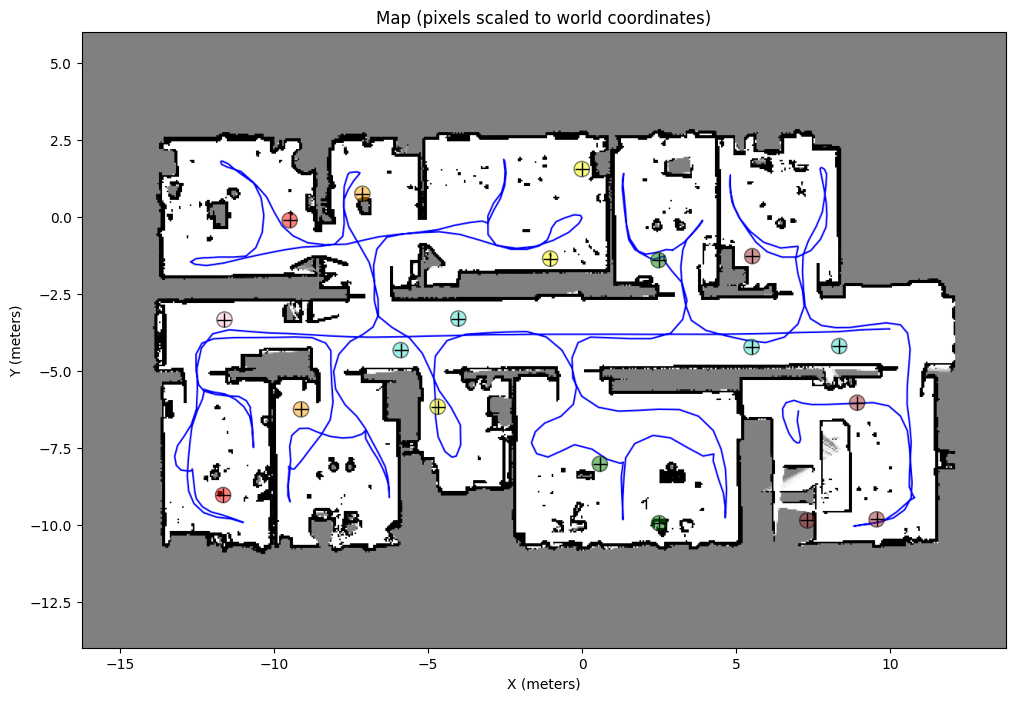

In [2]:
# Read world data, i.e. landmarks. The true landmark positions are not given to the FastSlam algorithm
landmarks_truth = read_world_data("world.data")

# Read sensor readings, i.e. odometry and range-bearing sensor
data = read_sensor_data("sensor_data.data")

# set the axis dimensions
plotter = Plotter(data, [], landmarks_truth)

In a typical SLAM setup, landmarks are conditionally independent given the robot trajectory. Consequently, information about the location of one landmark provides no additional information about the locations of the other landmarks.

In FastSLAM, the robot pose is estimated using a particle filter, while each landmark position is estimated using an EKF. This decomposition is enabled by Rao–Blackwellization, which exploits the conditional independence of landmarks given the robot trajectory.

Therefore, each particle of the class **``Particle``**  consists of a predicted robot pose, a list of landmark EKFs of the class **``LandmarkEKF``**, and a specific particle weight - indiciating the likelihood of this particle. In the following taks, you will complete the **``Particle``** class.

In [3]:
robot_init_pose = [0, 0,0]
motion_noise = [0.1 ,0.5, 0.1]

particle = Particle(1, motion_noise, [1,1], robot_init_pose)

---
## 7.1 Prediction [2.0]
Complete the `prediction_step` of the **``Particle``**.

The input to this function is of type **Odometry**, which contains: 
- r1: First rotation ($\Delta\theta_1$).
- t: Translation ($\Delta d$).
- r2: Second rotation ($\Delta\theta_2$).

The standard deviations of the motion noise is defined within the function.

**Hint:** Make sure you do not change the shape of self.pose!

In [4]:
odom = Odometry(0,1,0)
particle.prediction_step(odom)

new_pose = particle.pose
shape_check("Particle pose", new_pose, (3, 1))


---
## VISUALIZE [0.0]

To see the FastSLAM in action, run the **ex7.py** direclty in the console !

All required parameters are stored in params.txt. You can change all of the but make sure they are reasonable! 

For example, you can reduce the number of particles or change the noise parameters.

In [5]:
# how many particles
num_particles = 50

# Noise parameters
motion_noise = [0.0005, 0.001, 0.0005]
sensor_noise = [0.001, 0.0005]

p={"num_particles":num_particles,"motion_noise":motion_noise,"sensor_noise":sensor_noise}
save_params(p)



---
## 7.2 Measurement Model [2.0]
Complete the `measurement_model` of the **``Particle``** class. 

The input to this function is of type **LandmarkEKF**, which contains: 
- the predicted position of the landmark,
- the covariance of the observation noise,
- a flag indicating whether the landmark has been observed before.

The task is to compute the expected measurement **h** for a landmark and the corresponding Jacobian **H**


In [6]:
landmark = particle.landmarks[0]
h, H = particle.measurement_model(landmark)

shape_check("Measurement Model h", h, (2,))
shape_check("Measurement Model H", H, (2, 2))

---
## 7.3 Correction [6.0]
Complete the `correction_step` of the **``Particle``** class.

The input to this function is of class **``SensorMeasurement``**, which contains: 
- list of landmarks,
    - landmark_id : observed landmark ID,
    - z_range     : measured distance to the landmark in meters
    - z_bearing   : measured angular direction of the landmark in radians  

The range-bearing measurment model is defined as:

$$
h(p_r, p_l) =
\begin{bmatrix}
r \\
\phi
\end{bmatrix}
=
\begin{bmatrix}
\sqrt{(x_l - x_r)^2 + (y_l - y_r)^2} \\
\operatorname{atan2}(y_l - y_r, x_l - x_r) - \theta_r
\end{bmatrix}
$$

and the inverse:

$$
h^{-1}(p_r, r, \phi) =
\begin{bmatrix}
x_l \\
y_l
\end{bmatrix}
=
\begin{bmatrix}
x_r + r \cos(\phi + \theta_r) \\
y_r + r \sin(\phi + \theta_r)
\end{bmatrix}
$$


### Task A

For previously unseen landmarks, there is no prior knowledge about their location, and therefore the normal EKF update cannot be applied. Instead the landmark state is initialized using the inverse observation model, which maps the sensor measurement (range and bearing) and the current robot pose into the landmark’s estimated position.

The corresponding covariance is computed by propagating the measurement noise (and robot pose uncertainty) through the linearized inverse observation model. Since landmarks are assumed to be static, no process noise is added to their state.


### Task B

Once initialized, the landmark state is updated using the standard EKF measurement update. The predicted measurement is computed from the current landmark estimate and robot pose using the forward observation model, and the difference between the actual and predicted measurement.


### Task C
For previous observed landmarks, the likelihood of a single measurement is computed. As the measurments of multiple landmarks are assumed to be independent, the joint likelihood is used to update the particle weight.


In [7]:
landmark_id = 0
z_range = 10
z_bearing = np.pi/2

sensor_measurements = [SensorMeasurement(landmark_id,z_range,z_bearing)]

particle.correction_step(sensor_measurements)
particle._shape_check()

---
## 7.4 Selective Resampling [5.0]
To reduces the risk of particle depletion, an improved approach is described in [Improving Grid-based SLAM with Rao-Blackwellized Particle Filters](http://www2.informatik.uni-freiburg.de/~burgard/postscripts/grisetti05icra.pdf).

Instead of resampling after a fixed amount of timesteps, the "number of effective particles" approach resamples only when 
necessary. 

Complete the `fast_slam_resampling` and the underlying `low_variance_resampler`.

In [ ]:
#Use Selective resampling
p={"num_iterations_resample":"selective"}
save_params(p)

In [9]:

#Resample after fixed number of iterations (eg. 100)
p={"num_iterations_resample":100}
save_params(p)

In [10]:

#No resampling
p={"num_iterations_resample":"off"}
save_params(p)

In [11]:

#Resample after fixed number of iterations (eg. 100)
p={"num_iterations_resample":"selective", "noise_odomdata":0.01}
save_params(p)